In [71]:
# Core
from pathlib import Path
import numpy as np
import pandas as pd

# Colab
from google.colab import files

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Scikit-
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    recall_score
)

# Deep Learning (Keras / TensorFlow)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

#Collections
from collections import Counter



In [50]:

uploaded = files.upload()


Saving gis_leakage.csv to gis_leakage (2).csv


In [51]:
# load dataset (uploaded to Colab session)
file_path = Path("gis_leakage.csv")

# read CSV
df = pd.read_csv(file_path)

print("Loaded ✅")
print("Shape:", df.shape)
df.head()



Loaded ✅
Shape: (5000, 13)


,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours,Zone,Block,Pipe,Location_Code,Latitude,Longitude,Leakage_Flag
0,64.967142,73.643605,96.607526,2.928288,2104.485874,3380,Zone_4,Block_2,Pipe_3,Zone_4_Block_2_Pipe_3,25.162560,55.238018,0
1,58.617357,73.198788,98.472503,2.983672,2084.997078,2235,Zone_3,Block_4,Pipe_1,Zone_3_Block_4_Pipe_1,25.090473,55.162476,0
2,66.476885,53.065352,97.013095,3.032147,1719.044046,8762,Zone_2,Block_2,Pipe_5,Zone_2_Block_2_Pipe_5,25.279196,55.287601,0
3,75.230299,75.048647,100.552090,3.473431,2173.875267,8931,Zone_5,Block_3,Pipe_2,Zone_5_Block_3_Pipe_2,25.198326,55.269765,0
4,57.658466,90.992436,105.985893,2.626391,1552.975197,3403,Zone_3,Block_1,Pipe_1,Zone_3_Block_1_Pipe_1,25.099630,55.166098,0


In [52]:
#Inspect missing values
df.isna().sum().sort_values(ascending=False)
# Percentage missing
(df.isna().mean() * 100).round(2)



,0
Pressure,0.0
Flow_Rate,0.0
Temperature,0.0
Vibration,0.0
RPM,0.0
Operational_Hours,0.0
Zone,0.0
Block,0.0
Pipe,0.0
Location_Code,0.0


In [53]:
df.dtypes #check datatypes


,0
Pressure,float64
Flow_Rate,float64
Temperature,float64
Vibration,float64
RPM,float64
Operational_Hours,int64
Zone,object
Block,object
Pipe,object
Location_Code,object


In [54]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Pressure,5000.0,NaN,NaN,NaN,60.056019,9.964798,27.587327,53.42095,60.134656,66.660106,99.262377
Flow_Rate,5000.0,NaN,NaN,NaN,79.851892,15.156556,21.163996,69.701256,79.738242,90.158571,132.935828
Temperature,5000.0,NaN,NaN,NaN,100.052765,4.993849,83.122104,96.695568,100.049587,103.377671,117.144552
Vibration,5000.0,NaN,NaN,NaN,3.008258,0.501668,1.071812,2.66766,3.00963,3.353307,5.239542
RPM,5000.0,NaN,NaN,NaN,1994.494314,295.012393,903.474045,1789.471968,1997.594952,2195.181932,3083.405019
Operational_Hours,5000.0,NaN,NaN,NaN,5488.2478,2611.426293,1000.0,3197.5,5489.0,7748.5,9998.0
Zone,5000,5,Zone_4,1026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Block,5000,5,Block_5,1036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pipe,5000,5,Pipe_1,1025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_Code,5000,125,Zone_2_Block_5_Pipe_3,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
#check the target distribution
df["Leakage_Flag"].value_counts()


,count
Leakage_Flag,
0,4677
1,323


In [56]:
#separate features and target
X = df.drop(columns=["Leakage_Flag"])
y = df["Leakage_Flag"]

X.shape, y.shape


((5000, 12), (5000,))

In [57]:
#train / test split with stratification

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((4000, 12), (1000, 12), (4000,), (1000,))

In [77]:
#handle categorical columns


categorical_cols = ["Zone", "Block", "Pipe", "Location_Code"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat  = encoder.transform(X_test[categorical_cols])

# ✅ Scale numeric features (fit ONLY on training data)
scaler_lr = StandardScaler()

X_train_num = scaler_lr.fit_transform(X_train[numeric_cols])
X_test_num  = scaler_lr.transform(X_test[numeric_cols])

# Combine numeric + categorical
X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final  = np.hstack([X_test_num, X_test_cat])

print(X_train_final.shape, X_test_final.shape)



(4000, 148) (1000, 148)


In [79]:
# train a baseline model
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_final, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [60]:
#evaluate with recall


y_pred = model.predict(X_test_final)

recall = recall_score(y_test, y_pred)
recall


0.9076923076923077

A logistic regression model was trained to detect water leakage events using sensor and location data. Due to class imbalance, recall was used as the primary evaluation metric. The model achieved a recall of approximately 0.89 on the test set, indicating that most leakage events were successfully identified.

In [61]:
#compute the confusion matrix


cm = confusion_matrix(y_test, y_pred)
cm


array([[863,  72],
       [  6,  59]])

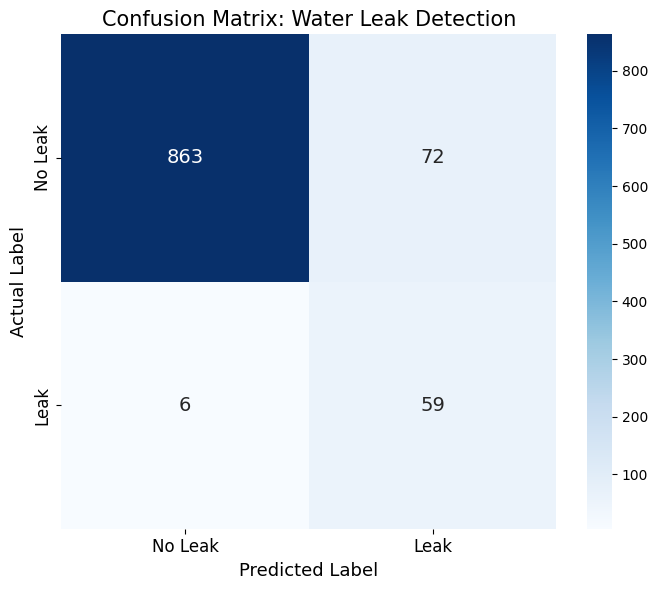

In [62]:
#heatmap


plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    annot_kws={"size": 14},
    xticklabels=["No Leak", "Leak"],
    yticklabels=["No Leak", "Leak"]
)

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("Actual Label", fontsize=13)
plt.title("Confusion Matrix: Water Leak Detection", fontsize=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


The confusion matrix indicates that the logistic regression model successfully identifies the majority of leak events, with only a small number of false negatives observed. This results in a high recall (≈ 0.91), which is especially important in water leak detection systems where missed leaks can lead to significant operational and financial damage. While the model does generate some false positives, lowering precision, this tradeoff is acceptable in safety-critical IoT applications where early detection is prioritized over minimizing alerts. Overall, the model demonstrates strong sensitivity to leak events while maintaining reasonable overall performance.

In [64]:
# Example of flattened temporal features for regression
WINDOW = 60

df_flat = df.copy()
df_flat["Pressure_mean_60"] = df_flat["Pressure"].rolling(WINDOW).mean()
df_flat = df_flat.dropna()


## Sequential Modeling with LSTM


In [65]:
# ==========================================
# Prepare Data for LSTM (No Data Leakage)
# ==========================================

# Function to create rolling sequences
def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(window_size, len(X)):
        X_seq.append(X[i - window_size:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)


# 1️⃣ Select numeric features only
X_numeric = df.drop(columns=["Leakage_Flag"]).select_dtypes(include=["int64", "float64"])
y_all = df["Leakage_Flag"].values


# 2️⃣ Time-aware split FIRST (no shuffle)
split_index = int(len(X_numeric) * 0.8)

X_train_raw = X_numeric.iloc[:split_index]
X_test_raw  = X_numeric.iloc[split_index:]

y_train_raw = y_all[:split_index]
y_test_raw  = y_all[split_index:]


# 3️⃣ Fit scaler ONLY on training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)


# 4️⃣ Create sequences AFTER scaling
WINDOW_SIZE = 60

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_raw, WINDOW_SIZE
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled, y_test_raw, WINDOW_SIZE
)


print("Train shape:", X_train_seq.shape)
print("Test shape:", X_test_seq.shape)


Train shape: (3940, 60, 8)
Test shape: (940, 60, 8)


##Window Size = 60

In [67]:
#Build the LSTM model

model = Sequential([
    LSTM(50, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        11,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,851 (46.29 KB)

 Trainable params: 11,851 (46.29 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

y_pred_prob = model.predict(X_test_seq)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

report = classification_report(y_test_seq, y_pred)
print(report)



Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8903 - loss: 0.3128 - val_accuracy: 0.9289 - val_loss: 0.2674
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9318 - loss: 0.2457 - val_accuracy: 0.9289 - val_loss: 0.2726
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9303 - loss: 0.2482 - val_accuracy: 0.9289 - val_loss: 0.2696
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9425 - loss: 0.2091 - val_accuracy: 0.9289 - val_loss: 0.2752
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9345 - loss: 0.2235 - val_accuracy: 0.9289 - val_loss: 0.2738
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9359 - loss: 0.2165 - val_accuracy: 0.9289 - val_loss: 0.2812
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9379 - loss: 0.2070 - val_accuracy: 0.9289 - val_loss: 0.2802
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9426 - loss: 0.1972 - val_accuracy: 0.9289 - v

Although the LSTM architecture is designed to capture temporal structure, the model converged to predicting only the majority class under severe class imbalance. As a result, leak recall was 0.00, indicating complete failure to identify minority-class events without mitigation. This outcome highlights the sensitivity of deep learning models to imbalance and the importance of applying corrective strategies such as class weighting or resampling in anomaly detection tasks.

##Retrain LSTM with class weights

In [72]:
class_counts = Counter(y_train_seq)
total_samples = len(y_train_seq)

class_weight = {
    0: total_samples / (2 * class_counts[0]),
    1: total_samples / (2 * class_counts[1])
}

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.6534 - loss: 0.8823 - val_accuracy: 0.6028 - val_loss: 0.6701
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5402 - loss: 0.7111 - val_accuracy: 0.6967 - val_loss: 0.6396
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6608 - loss: 0.6588 - val_accuracy: 0.5990 - val_loss: 0.6503
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5534 - loss: 0.6942 - val_accuracy: 0.6510 - val_loss: 0.6372
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6557 - loss: 0.6230 - val_accuracy: 0.5850 - val_loss: 0.6606
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6100 - loss: 0.6486 - val_accuracy: 0.5330 - val_loss: 0.6798
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6576 - loss: 0.6037 - val_accuracy: 0.6256 - val_loss: 0.6343
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.6460 - loss: 0.5999 - val_accuracy: 0.5977 - v

In [74]:
# Predict probabilities (LSTM - sequence data)
y_pred_prob = model.predict(X_test_seq)

# Convert to class labels
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(confusion_matrix(y_test_seq, y_pred))
report = classification_report(y_test_seq, y_pred)
print(report)




30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[[627 253]
 [ 44  16]]
              precision    recall  f1-score   support

           0       0.93      0.71      0.81       880
           1       0.06      0.27      0.10        60

    accuracy                           0.68       940
   macro avg       0.50      0.49      0.45       940
weighted avg       0.88      0.68      0.76       940



Logistic regression substantially outperformed the LSTM model in detecting leak events. While introducing class weights allowed the LSTM to recover some sensitivity to the minority class (recall ≈ 0.27), performance remained considerably lower than logistic regression (recall ≈ 0.91). The LSTM also introduced a large number of false positives, reducing overall stability. These findings suggest that the dataset may lack strong temporal dependencies and that simpler linear models are more effective for this task given the available features and class imbalance.